In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
import joblib


In [21]:
data = pd.read_csv('../data/heart_2020_cleaned.csv')
data.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [23]:
for col in data.columns:
    print(f'{col}: {data[col].unique()}')

HeartDisease: ['No' 'Yes']
BMI: [16.6  20.34 26.58 ... 62.42 51.46 46.56]
Smoking: ['Yes' 'No']
AlcoholDrinking: ['No' 'Yes']
Stroke: ['No' 'Yes']
PhysicalHealth: [ 3.  0. 20. 28.  6. 15.  5. 30.  7.  1.  2. 21.  4. 10. 14. 18.  8. 25.
 16. 29. 27. 17. 24. 12. 23. 26. 22. 19.  9. 13. 11.]
MentalHealth: [30.  0.  2.  5. 15.  8.  4.  3. 10. 14. 20.  1.  7. 24.  9. 28. 16. 12.
  6. 25. 17. 18. 21. 29. 22. 13. 23. 27. 26. 11. 19.]
DiffWalking: ['No' 'Yes']
Sex: ['Female' 'Male']
AgeCategory: ['55-59' '80 or older' '65-69' '75-79' '40-44' '70-74' '60-64' '50-54'
 '45-49' '18-24' '35-39' '30-34' '25-29']
Race: ['White' 'Black' 'Asian' 'American Indian/Alaskan Native' 'Other'
 'Hispanic']
Diabetic: ['Yes' 'No' 'No, borderline diabetes' 'Yes (during pregnancy)']
PhysicalActivity: ['Yes' 'No']
GenHealth: ['Very good' 'Fair' 'Good' 'Poor' 'Excellent']
SleepTime: [ 5.  7.  8.  6. 12.  4.  9. 10. 15.  3.  2.  1. 16. 18. 14. 20. 11. 13.
 17. 24. 19. 21. 22. 23.]
Asthma: ['Yes' 'No']
KidneyDisease: 

In [24]:
encode=LabelEncoder()

data['GenHealth']=encode.fit_transform(data['GenHealth'])
data['Race']=encode.fit_transform(data['Race'])

In [25]:
for col in data.columns:
    data[col] = data[col].replace('Yes',1)
    data[col] = data[col].replace('No',0)
    data[col] = data[col].replace('Male',1)
    data[col] = data[col].replace('Female',0)
    data[col] = data[col].replace('No, borderline diabetes',0)
    data[col] = data[col].replace('Yes (during pregnancy)',1)

   

C:\Users\wajiz.pk\AppData\Local\Temp\ipykernel_15876\3974928297.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].replace('No',0)
C:\Users\wajiz.pk\AppData\Local\Temp\ipykernel_15876\3974928297.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col] = data[col].replace('Female',0)
C:\Users\wajiz.pk\AppData\Local\Temp\ipykernel_15876\3974928297.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `resul

In [26]:
# Bin AgeCategory into broader groups
def bin_age_category(age):
    if age in ['18-24', '25-29', '30-34']:
        return "Young"
    elif age in ['35-39', '40-44', '45-49', '50-54', '55-59', '60-64']:
        return "Middle-aged"
    else:
        return "Senior"

# Apply the binning
data["BinnedAge"] = data["AgeCategory"].apply(bin_age_category)

# One-hot encode the new BinnedAge feature
data = pd.get_dummies(data, columns=["BinnedAge"], )


In [27]:
data=data.drop(['AgeCategory'],axis=1)

In [28]:
data.corr()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,BinnedAge_Middle-aged,BinnedAge_Senior,BinnedAge_Young
HeartDisease,1.000000,0.051803,0.107764,-0.032080,0.196835,0.170721,0.028591,0.201258,0.070040,0.034854,0.174782,-0.100030,-0.011062,0.008327,0.041444,0.145197,0.093317,-0.102665,0.210385,-0.127840
BMI,0.051803,1.000000,0.023118,-0.038816,0.019733,0.109788,0.064131,0.181678,0.026940,-0.037424,0.200443,-0.150616,0.035932,-0.051822,0.092345,0.050768,-0.033644,0.120066,-0.061258,-0.080632
Smoking,0.107764,0.023118,1.000000,0.111768,0.061226,0.115352,0.085157,0.120074,0.085052,0.065499,0.055544,-0.097174,0.020625,-0.030336,0.024149,0.034920,0.033977,0.022406,0.080693,-0.129782
AlcoholDrinking,-0.032080,-0.038816,0.111768,1.000000,-0.019858,-0.017254,0.051282,-0.035328,0.004200,0.036702,-0.057786,0.017487,0.001629,-0.005065,-0.002202,-0.028280,-0.005702,0.036378,-0.059147,0.026119
Stroke,0.196835,0.019733,0.061226,-0.019858,1.000000,0.137014,0.046467,0.174143,-0.003091,-0.003956,0.104467,-0.079455,-0.009335,0.011900,0.038866,0.091167,0.048116,-0.051254,0.117940,-0.079898
PhysicalHealth,0.170721,0.109788,0.115352,-0.017254,0.137014,1.000000,0.287987,0.428373,-0.040904,-0.000847,0.153975,-0.232283,-0.035703,-0.061387,0.117907,0.142197,0.041700,0.007685,0.064020,-0.089777
MentalHealth,0.028591,0.064131,0.085157,0.051282,0.046467,0.287987,1.000000,0.152235,-0.100058,-0.014491,0.029709,-0.095808,-0.004412,-0.119717,0.114008,0.037281,-0.033412,0.042753,-0.131317,0.107670
DiffWalking,0.201258,0.181678,0.120074,-0.035328,0.174143,0.428373,0.152235,1.000000,-0.068860,-0.015831,0.209255,-0.278524,-0.043552,-0.022216,0.103222,0.153064,0.064840,-0.058051,0.186440,-0.156326
Sex,0.070040,0.026940,0.085052,0.004200,-0.003091,-0.040904,-0.100058,-0.068860,1.000000,0.018855,-0.002054,0.048247,-0.010283,-0.015704,-0.069191,-0.009084,0.013434,0.007607,-0.051006,0.053582
Race,0.034854,-0.037424,0.065499,0.036702,-0.003956,-0.000847,-0.014491,-0.015831,0.018855,1.000000,-0.046062,0.056767,0.050344,0.035889,-0.017975,0.003709,0.134780,-0.042938,0.132936,-0.109444


In [29]:
get_corr_col=[]
corr=data.corr()
for col in data.columns:
    if corr[col][0]>0.1:
        get_corr_col.append(col)

C:\Users\wajiz.pk\AppData\Local\Temp\ipykernel_15876\3600281321.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if corr[col][0]>0.1:


In [30]:
get_corr_col = get_corr_col + ['BinnedAge_Middle-aged', 'BinnedAge_Young']
get_corr_col

['HeartDisease',
 'Smoking',
 'Stroke',
 'PhysicalHealth',
 'DiffWalking',
 'Diabetic',
 'KidneyDisease',
 'BinnedAge_Senior',
 'BinnedAge_Middle-aged',
 'BinnedAge_Young']

In [31]:
x = data[get_corr_col].drop(['HeartDisease'], axis=1)
y = data['HeartDisease']

In [32]:
x_test, x_train, y_test, y_train = train_test_split(x, y, test_size=0.3, random_state=42)

In [33]:
from imblearn.under_sampling import RandomUnderSampler

# Initialize RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)

# Apply undersampling
x_train_bal, y_train_bal = undersampler.fit_resample(x_train, y_train)

# Check the new class distribution
from collections import Counter
print("Class distribution after downsampling:", Counter(y_train_bal))


Class distribution after downsampling: Counter({0: 8290, 1: 8290})


In [34]:
print(y_train_bal.value_counts())
print(x_train.describe())


HeartDisease
0    8290
1    8290
Name: count, dtype: int64
            Smoking        Stroke  PhysicalHealth   DiffWalking      Diabetic  \
count  95939.000000  95939.000000    95939.000000  95939.000000  95939.000000   
mean       0.411355      0.038222        3.394011      0.139974      0.134721   
std        0.492082      0.191733        7.988088      0.346962      0.341427   
min        0.000000      0.000000        0.000000      0.000000      0.000000   
25%        0.000000      0.000000        0.000000      0.000000      0.000000   
50%        0.000000      0.000000        0.000000      0.000000      0.000000   
75%        1.000000      0.000000        2.000000      0.000000      0.000000   
max        1.000000      1.000000       30.000000      1.000000      1.000000   

       KidneyDisease  
count   95939.000000  
mean        0.036648  
std         0.187898  
min         0.000000  
25%         0.000000  
50%         0.000000  
75%         0.000000  
max         1.000000  


In [35]:
x_train_bal 

,Smoking,Stroke,PhysicalHealth,DiffWalking,Diabetic,KidneyDisease,BinnedAge_Senior,BinnedAge_Middle-aged,BinnedAge_Young
215720,1,0,0.0,0,0,0,True,False,False
150963,0,0,0.0,0,0,0,False,False,True
165110,1,0,0.0,0,0,0,True,False,False
452,1,0,0.0,0,0,0,True,False,False
147063,1,0,3.0,0,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...
269610,0,0,0.0,0,0,0,True,False,False
106729,1,0,0.0,0,0,0,True,False,False
187544,0,0,0.0,1,0,0,True,False,False
173608,0,0,0.0,0,0,0,True,False,False


In [36]:


# Create the pipeline with age mapping
pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42, max_depth=30, max_features=0.5))
])

# Train the pipeline
pipeline.fit(x_train_bal, y_train_bal)

# Save the trained pipeline
joblib.dump(pipeline, "./model/heart_disease_pipeline.pkl")
print("Pipeline with age mapping saved successfully!")

# Evaluate the model
y_pred = pipeline.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Pipeline with age mapping saved successfully!
Accuracy: 0.7237509827746409
Precision: 0.19693511574828823
Recall: 0.7279777812712885
F1 Score: 0.31000624832634116

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.72      0.83    204773
           1       0.20      0.73      0.31     19083

    accuracy                           0.72    223856
   macro avg       0.58      0.73      0.57    223856
weighted avg       0.90      0.72      0.78    223856



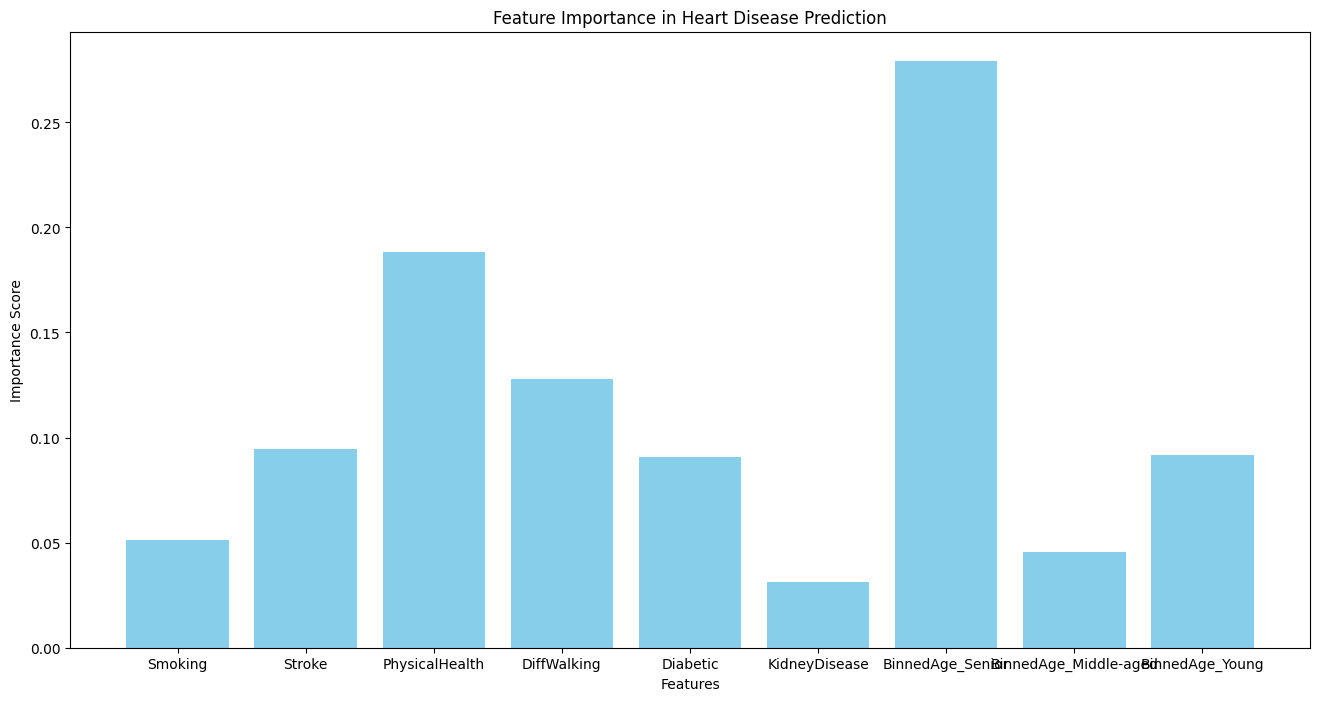

In [37]:
# Plot feature importance
importances = pipeline.named_steps['classifier'].feature_importances_
features = get_corr_col[1:]  # Exclude 'HeartDisease' from the feature list

plt.figure(figsize=(16, 8))
plt.bar(features, importances, color="skyblue")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Feature Importance in Heart Disease Prediction")
plt.show()


In [39]:
x_train_bal

,Smoking,Stroke,PhysicalHealth,DiffWalking,Diabetic,KidneyDisease,BinnedAge_Senior,BinnedAge_Middle-aged,BinnedAge_Young
215720,1,0,0.0,0,0,0,True,False,False
150963,0,0,0.0,0,0,0,False,False,True
165110,1,0,0.0,0,0,0,True,False,False
452,1,0,0.0,0,0,0,True,False,False
147063,1,0,3.0,0,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...
269610,0,0,0.0,0,0,0,True,False,False
106729,1,0,0.0,0,0,0,True,False,False
187544,0,0,0.0,1,0,0,True,False,False
173608,0,0,0.0,0,0,0,True,False,False


In [40]:

# Load the saved pipeline
pipeline = joblib.load("./model/heart_disease_pipeline.pkl")

# Sample Input
feature_names = ["Smoking", "Stroke", "PhysicalHealth", "DiffWalking", "Diabetic", "KidneyDisease", "BinnedAge_Senior", "BinnedAge_Middle-aged", "BinnedAge_Young"]
sample_input = pd.DataFrame([[1, 1, 18, 1, 1, 1, 0, 0, 1]], columns=feature_names)

# Prediction using the pipeline
prediction = pipeline.predict(sample_input)

print("Prediction:", "Heart Disease" if prediction[0] == 1 else "No Heart Disease")


Prediction: Heart Disease
